In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os

from partd import python

import sys
sys.path.append(os.path.abspath('../../'))
from utils_mitgcm import *
from utils_modal_analysis import _match_mode_to_field, project_vector_mode

# Load MITgcm results

In [5]:
lake = 'neuchatel'
model = f'{lake}_2025'

In [6]:
mitgcm_config, ds_full = open_mitgcm_ds_from_config('../../config.json', model)
base_folder_path = os.path.dirname(mitgcm_config['datapath'])

In [7]:
horizontal_resolution = 100
ds_full['YG'] = np.arange(0, len(ds_full['YG'])) * horizontal_resolution
ds_full['XG'] = np.arange(0, len(ds_full['XG'])) * horizontal_resolution
ds_full['YC'] = np.arange(1, len(ds_full['YC'])+1) * horizontal_resolution - horizontal_resolution/2
ds_full['XC'] = np.arange(1, len(ds_full['XC'])+1) * horizontal_resolution - horizontal_resolution/2

In [8]:
output_folder = os.path.join(base_folder_path, "modal_analysis")

In [26]:
import pandas as pd
crop_range = slice(pd.to_datetime("2025-04-01"), pd.to_datetime("2025-12-01"))

In [27]:
ds_full.isel(XC=200,YC=50).sel(time=crop_range).THETA.plot(y='Z')

KeyboardInterrupt: 

In [28]:
Zidx_range = range(0,80)
ds_crop = ds_full.sel(time=crop_range).isel(Z=Zidx_range, Zl=Zidx_range, Zp1=Zidx_range, Zu=Zidx_range)

# Load mode structure

In [13]:
mode_vel = xr.open_dataset(os.path.join(base_folder_path, "modal_analysis", "2025-08-07", "35h_mode6.nc"))

In [14]:
x_grid, y_grid = np.meshgrid(mode_vel.XC, mode_vel.YC)

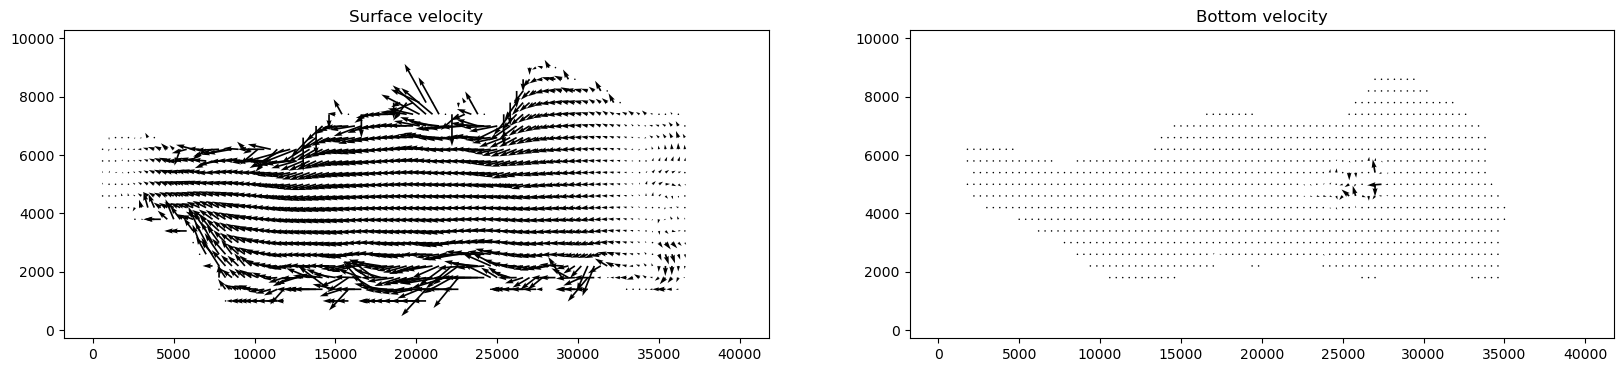

In [15]:
fig = plt.figure(figsize=(20,4))
ax1 = plt.subplot(1,2,1)
plt.title('Surface velocity')
ax1.quiver(x_grid, y_grid, mode_vel.u1_real[:,:-1], mode_vel.v1_real[:-1:], scale=1e-6, angles='xy', scale_units='xy', color='k')
ax2 = plt.subplot(1,2,2)
plt.title('Bottom velocity')
plt.quiver(x_grid, y_grid, mode_vel.u2_real[:,:-1], mode_vel.v2_real[:-1:], scale=5e-6, angles='xy', scale_units='xy', color='k')

# Project mode on MITgcm results

In [16]:
mode_vel['u1'] = (mode_vel.u1_real + 1j * mode_vel.u1_imag).fillna(0)
mode_vel['v1'] = (mode_vel.v1_real + 1j * mode_vel.v1_imag).fillna(0)
mode_vel['u2'] = (mode_vel.u2_real + 1j * mode_vel.u2_imag).fillna(0)
mode_vel['v2'] = (mode_vel.v2_real + 1j * mode_vel.v2_imag).fillna(0)

In [17]:
h1_mode = mode_vel.h1.values
print(h1_mode)

12.753427016068088


In [18]:
mode_u1 = mode_vel.u1.expand_dims(Z=ds_crop.Z.where(ds_crop.Z >= -1*h1_mode, drop=True))
mode_v1 = mode_vel.v1.expand_dims(Z=ds_crop.Z.where(ds_crop.Z >= -1*h1_mode, drop=True))
mode_u2 = mode_vel.u1.expand_dims(Z=ds_crop.Z.where(ds_crop.Z < -1*h1_mode, drop=True))
mode_v2 = mode_vel.v1.expand_dims(Z=ds_crop.Z.where(ds_crop.Z < -1*h1_mode, drop=True))

In [19]:
mode_u = xr.concat([mode_u1, mode_u2], dim="Z")
mode_v = xr.concat([mode_v1, mode_v2], dim="Z")

In [29]:
U = ds_crop.UVEL
V = ds_crop.VVEL
dA = 100*100

idx_Z = 0
proj_results = project_vector_mode(U.isel(Z=idx_Z), V.isel(Z=idx_Z), dA, mode_u.isel(Z=idx_Z), mode_v.isel(Z=idx_Z), rho=1025.0)

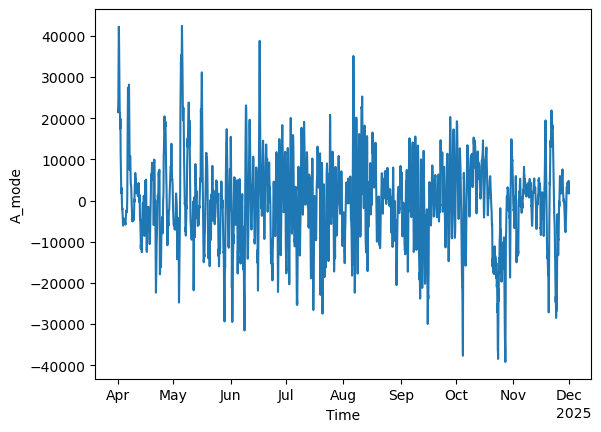

In [38]:
proj_results['A_real'].plot()

In [ ]:
proj_each_slice = []
KE_arr = []
A_arr = []
for idx_Z in range(len(U.Z)):
    print(fr'Computing layer {idx_Z}')
    tmp_results = project_vector_mode(U.isel(Z=idx_Z), V.isel(Z=idx_Z), dA, mode_u.isel(Z=idx_Z), mode_v.isel(Z=idx_Z), rho=1025.0)
    proj_each_slice.append(tmp_results)
    KE_arr.append(tmp_results['KE'].expand_dims(Z=[ds_crop.Z.isel(Z=idx_Z)]))
    A_arr.append(tmp_results['A_da'].expand_dims(Z=[ds_crop.Z.isel(Z=idx_Z)]))

Computing layer 0
Mode norm² = 1.0
Computing layer 1
Mode norm² = 1.0
Computing layer 2
Mode norm² = 1.0
Computing layer 3
Mode norm² = 1.0
Computing layer 4
Mode norm² = 1.0
Computing layer 5
Mode norm² = 1.0
Computing layer 6
Mode norm² = 1.0
Computing layer 7
Mode norm² = 1.0
Computing layer 8
Mode norm² = 1.0
Computing layer 9
Mode norm² = 1.0
Computing layer 10
Mode norm² = 1.0
Computing layer 11
Mode norm² = 1.0
Computing layer 12
Mode norm² = 1.0
Computing layer 13
Mode norm² = 1.0
Computing layer 14
Mode norm² = 1.0
Computing layer 15
Mode norm² = 1.0
Computing layer 16
Mode norm² = 1.0
Computing layer 17
Mode norm² = 1.0
Computing layer 18
Mode norm² = 1.0
Computing layer 19
Mode norm² = 1.0
Computing layer 20
Mode norm² = 1.0
Computing layer 21
Mode norm² = 1.0
Computing layer 22
Mode norm² = 1.0
Computing layer 23
Mode norm² = 1.0
Computing layer 24
Mode norm² = 1.0
Computing layer 25
Mode norm² = 1.0
Computing layer 26
Mode norm² = 1.0
Computing layer 27
Mode norm² = 1.0
Co

In [150]:
xr_KE = xr.concat(KE_arr, dim="Z")

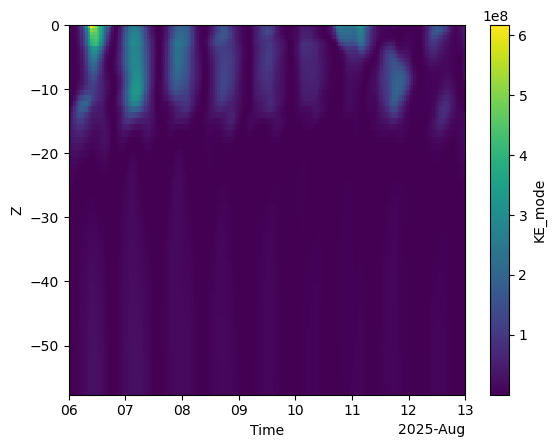

In [151]:
xr_KE.plot()

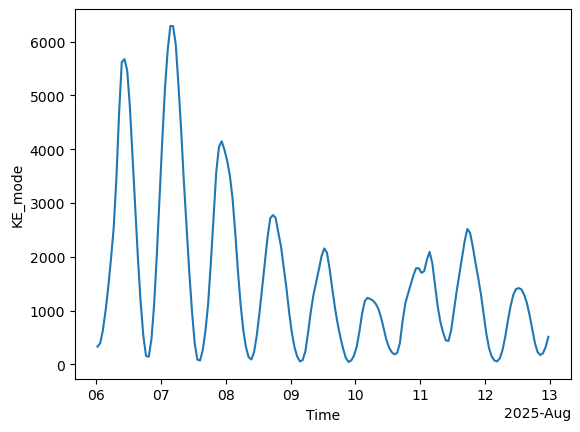

In [152]:
(xr_KE.sum(dim=['Z'])/1e6).plot()

In [153]:
xr_A = xr.concat(A_arr, dim="Z")

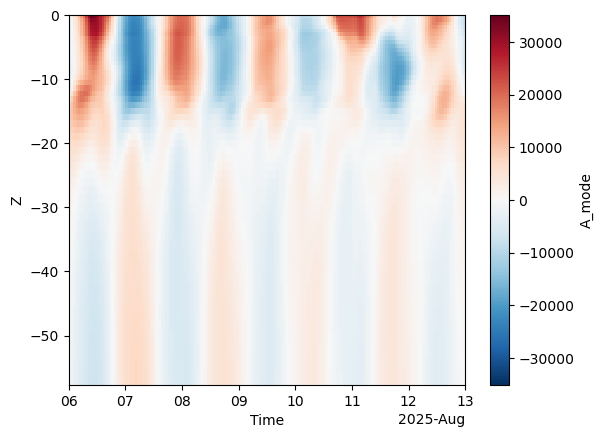

In [154]:
xr_A.real.plot()

# Plot

Text(0, 0.5, 'KE [MJ]')

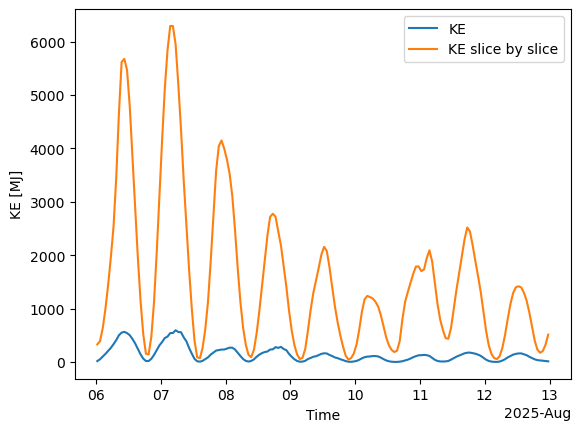

In [131]:
(proj_results['KE_da']*1e-6).plot(label='KE')
(xr_KE.sum(dim=['Z']) / 1e6).plot(label='KE slice by slice')
plt.legend()
plt.ylabel('KE [MJ]')

In [149]:
U_proj = proj_results['U_proj_phys'].rename({'XG':'XC'})
U_proj['XC'] = ds_crop.XC
V_proj = proj_results['V_proj_phys'].rename({'YG':'YC'})
V_proj['YC'] = ds_crop.YC

In [150]:
ke_phys = (
    0.5
    * 1025
    * (U_proj**2 + V_proj**2)
    * dA
    * ds_crop.drF
).sum(("Z","YC","XC"))

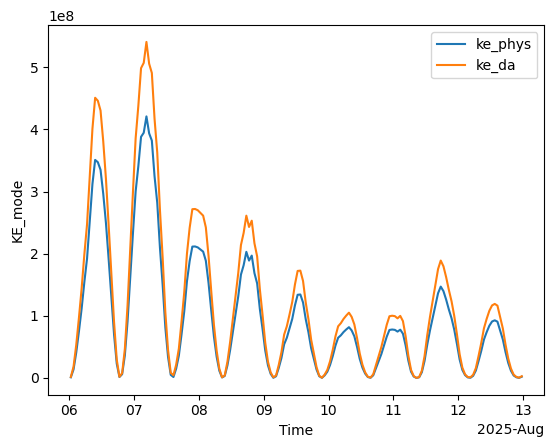

In [151]:
ke_phys.plot(label='ke_phys')
proj_results['KE_da'].plot(label='ke_da')
plt.legend()

# Compute KE tot for comparison

In [94]:
ds_crop_aligned, u_crop_aligned, v_crop_aligned, w_crop_aligned = align_coordinates(ds_crop)

In [95]:
from utils_energy_analysis import compute_ke
ke_tot = compute_ke(u_crop_aligned, v_crop_aligned, w_crop_aligned, 100, 100, ds_crop_aligned.drF)

In [96]:
ke_tot = ke_tot.sum(dim=['Z', 'YC', 'XC'])

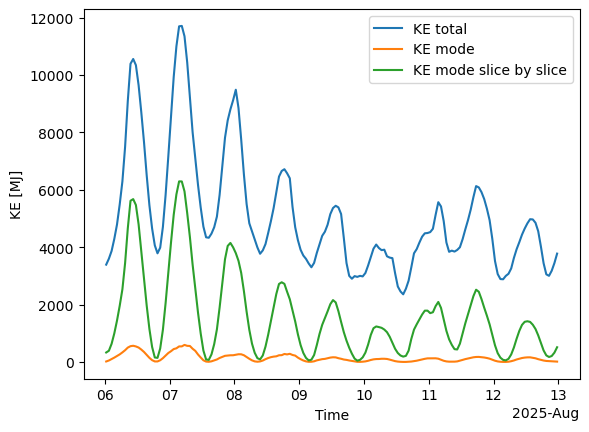

In [132]:
ke_tot.plot(label='KE total')
(proj_results['KE_da']/1e6).plot(label='KE mode')
(xr_KE.sum(dim=['Z'])/1e6).plot(label='KE mode slice by slice')
plt.ylabel('KE [MJ]')
plt.legend()

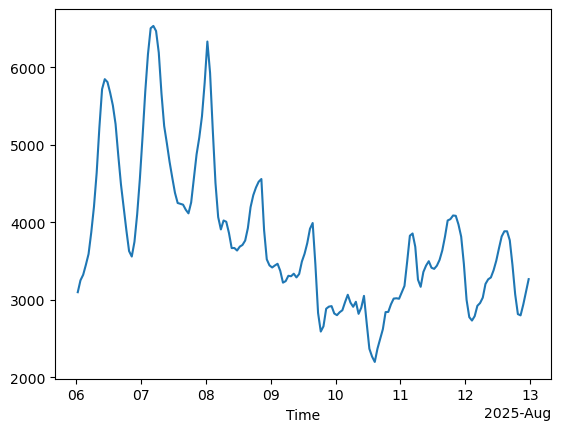

In [107]:
res = ke_tot - (xr_KE.sum(dim=['Z'])/1e6)
res.plot()

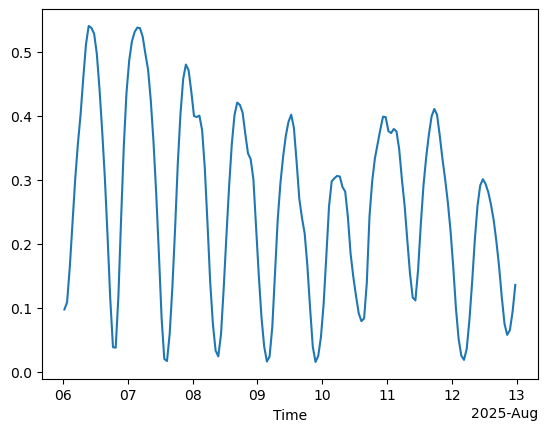

In [133]:
perc = (xr_KE.sum(dim=['Z'])/1e6) / ke_tot
perc.plot()

# Extra plots for fun

In [ ]:
from datetime import datetime

In [ ]:
mode_u.sel(XG=20000, YC=5000, method='nearest').real.plot(y='Z')

In [ ]:
U.sel(XG=20000, YC=5000, time=datetime(2025,8,8,0,0,0), method='nearest').plot(y='Z')

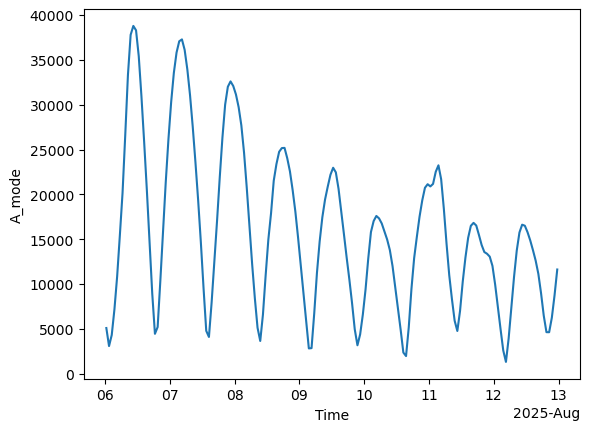

In [42]:
abs(proj_results['A_da']).plot()

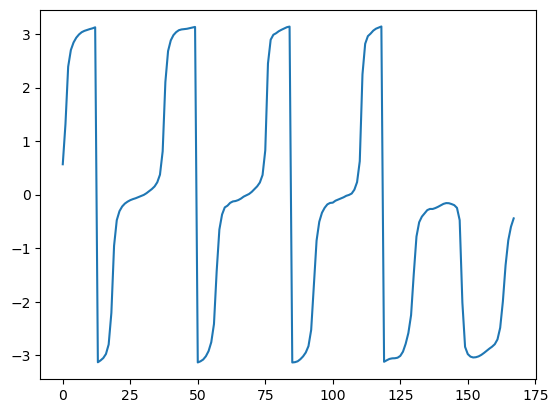

In [44]:
plt.plot(np.angle(proj_results['A_da']))